In [9]:
import numpy as np
import matplotlib.pyplot as plt
from potential import PotentialCalculator
from dft import DFT
from typing import List, Dict, Any

In [2]:
# Example configuration and parameters
config = {
    "npoints": 1000,
    "alpha": 0.5,  # For Ewald summation in Coulomb potential
}

system = {"ncomponents": 2, "potential": ["hs", "lj", "coulomb"]}

parameters = {
    "sigma": [1.0, 1.2],  # Diameter for each component
    "epsilon": [1.0, 1.5],  # LJ well depth for each component
    "charge": [1.0, -1.0],  # Charges for each component
}

constants = type("Constants", (), {"beta": 1.0})()  # Simple object to hold beta value

In [3]:
def create_distance_arrays(config, system):
    # Calculate deltar and deltak
    rmax = config.get("rmax", 10.0)  # Default to 10 if not specified
    deltar = rmax / config["npoints"]
    deltak = np.pi / (config["npoints"] * deltar)

    # Create r and k arrays
    r = np.arange(1, config["npoints"] + 1) * deltar
    k = np.arange(1, config["npoints"] + 1) * deltak

    return r, k, deltar, deltak

In [4]:
# Usage in main code:
r, k, deltar, deltak = create_distance_arrays(config, system)

# Update config with calculated values
config["deltar"] = deltar
config["deltak"] = deltak

In [5]:
dft = DFT(config["npoints"], deltar, deltak, r, k)

In [6]:
# Create PotentialCalculator instance
calculator = PotentialCalculator(config, system, parameters, constants)

# Calculate potentials
U_ij, U_ij_individual, dU_ij_individual, U_discontinuity, U_erf_ij = calculator.calculate_potentials(
    dft, r, k
)

# Calculate modified Mayer functions
modMayerFunc = calculator.def_modMayerFunc(U_ij, U_ij_individual, U_discontinuity, U_erf_ij["real"])

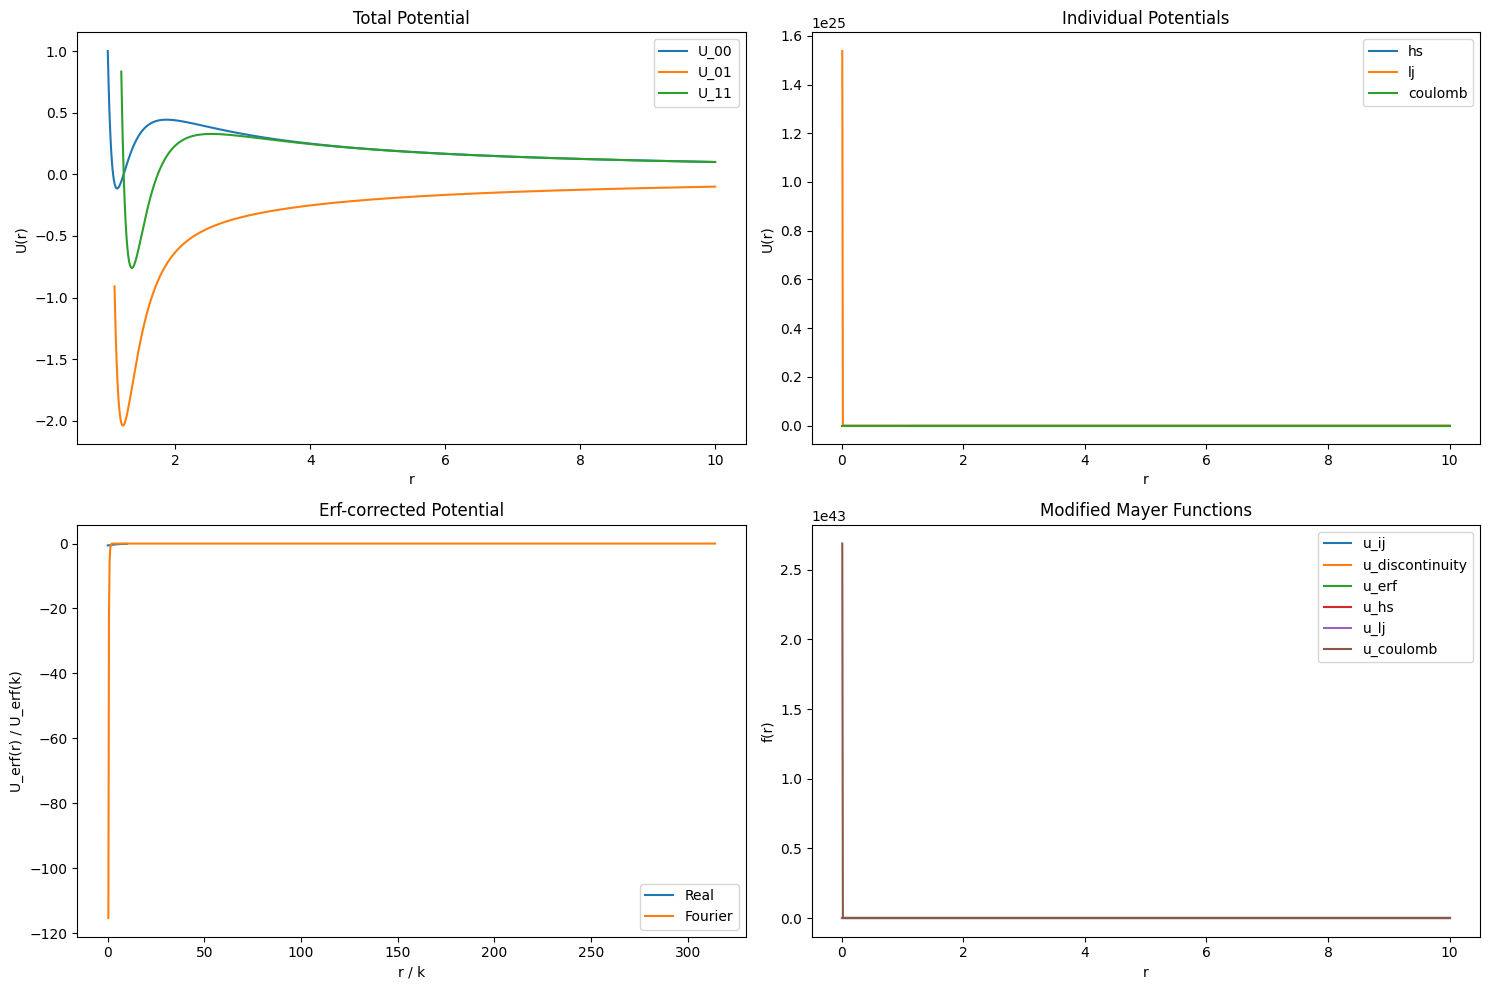

In [7]:
# Plotting
plt.figure(figsize=(15, 10))

# Plot total potential
plt.subplot(2, 2, 1)
plt.title("Total Potential")
for i in range(system["ncomponents"]):
    for j in range(i, system["ncomponents"]):
        plt.plot(r, U_ij[i, j], label=f"U_{i}{j}")
plt.xlabel("r")
plt.ylabel("U(r)")
plt.legend()

# Plot individual potentials
plt.subplot(2, 2, 2)
plt.title("Individual Potentials")
for pot_type in U_ij_individual:
    plt.plot(r, U_ij_individual[pot_type][0, 1], label=pot_type)
plt.xlabel("r")
plt.ylabel("U(r)")
plt.legend()

# Plot Erf-corrected potential
plt.subplot(2, 2, 3)
plt.title("Erf-corrected Potential")
plt.plot(r, U_erf_ij["real"][0, 1], label="Real")
plt.plot(k, U_erf_ij["fourier"][0, 1], label="Fourier")
plt.xlabel("r / k")
plt.ylabel("U_erf(r) / U_erf(k)")
plt.legend()

# Plot modified Mayer functions
plt.subplot(2, 2, 4)
plt.title("Modified Mayer Functions")
for key in modMayerFunc:
    plt.plot(r, modMayerFunc[key][0, 1], label=key)
plt.xlabel("r")
plt.ylabel("f(r)")
plt.legend()

plt.tight_layout()
plt.show()

In [28]:
import matplotlib.pyplot as plt
import numpy as np
from typing import Dict, Any


class PotentialPlotter:
    def __init__(
        self,
        r: np.ndarray,
        U_ij: np.ndarray,
        U_ij_individual: Dict[str, np.ndarray],
        config: Dict[str, Any],
        system: Dict[str, Any],
        parameters: Dict[str, Any],
        constants: Any,
    ):
        self.r = r
        self.U_ij = U_ij
        self.U_ij_individual = U_ij_individual
        self.config = config
        self.system = system
        self.parameters = parameters
        self.constants = constants
        self.fig, self.axs = plt.subplots(2, 2, figsize=(12, 10))
        self.axs = self.axs.flatten()
        self.y_min_default = -1e6  # Adjust as needed
        self.y_max_default = 1e6  # Adjust as needed
        self.x_max_default = 10  # Default x-axis maximum

    def plot_potentials(self, y_min_default=None, y_max_default=None, x_max=None):
        y_min = self.y_min_default if y_min_default is None else y_min_default
        y_max = self.y_max_default if y_max_default is None else y_max_default
        x_max = self.x_max_default if x_max is None else x_max

        self._plot_total_potential(y_min, y_max, x_max)
        self._plot_individual_potentials(y_min, y_max, x_max)
        self._adjust_layout()
        plt.show()

    def _plot_total_potential(self, y_min, y_max, x_max):
        ax = self.axs[0]
        for i in range(self.config["system"]["ncomponents"]):
            for j in range(i, self.config["system"]["ncomponents"]):
                ax.plot(self.r, self.U_ij[i, j], label=f"U_{i}{j}")
        ax.set_xlabel("r")
        ax.set_ylabel("U(r)")
        ax.set_title("Total Potential")
        ax.legend()
        self._auto_scale(ax, self.U_ij, y_min, y_max, x_max)

    def _plot_individual_potentials(self, y_min, y_max, x_max):
        individual_potentials = self.config["system"]["potential"]
        for i, pot in enumerate(individual_potentials, start=1):
            if i < 4:  # We only have 3 subplots for individual potentials
                ax = self.axs[i]
                if pot in self.U_ij_individual:
                    for m in range(self.config["system"]["ncomponents"]):
                        for n in range(m, self.config["system"]["ncomponents"]):
                            ax.plot(self.r, self.U_ij_individual[pot][m, n], label=f"{pot}_{m}{n}")
                    ax.set_xlabel("r")
                    ax.set_ylabel(f"U_{pot}(r)")
                    ax.set_title(f"{pot.upper()} Potential")
                    ax.legend()
                    self._auto_scale(ax, self.U_ij_individual[pot], y_min, y_max, x_max)

    def _auto_scale(self, ax, y, y_min_default, y_max_default, x_max):
        if y.ndim > 2:  # For multi-component systems
            y_flat = y.reshape(-1, y.shape[-1])
        else:
            y_flat = y.reshape(1, -1)

        # Find finite values
        finite_mask = np.isfinite(y_flat)
        if not np.any(finite_mask):
            print("Warning: No finite values found in the data.")
            ax.set_ylim(y_min_default, y_max_default)
            ax.set_xlim(0, x_max)
            return

        y_finite = y_flat[finite_mask]
        y_min = max(np.min(y_finite), y_min_default)
        y_max = min(np.max(y_finite), y_max_default)

        # Calculate gradient only for finite values
        gradients = []
        for y_i in y_flat:
            finite_indices = np.isfinite(y_i)
            if np.any(finite_indices):
                r_finite = self.r[finite_indices]
                grad = np.gradient(y_i[finite_indices], r_finite)
                gradients.append(np.max(np.abs(grad)))

        if gradients:
            dy = max(gradients)
        else:
            dy = 0

        # Find the region of interest
        threshold = dy * 0.01  # 1% of max derivative
        roi_mask = np.zeros_like(self.r, dtype=bool)
        for y_i in y_flat:
            finite_indices = np.isfinite(y_i)
            if np.any(finite_indices):
                r_finite = self.r[finite_indices]
                grad = np.gradient(y_i[finite_indices], r_finite)
                roi_mask[finite_indices] |= np.abs(grad) > threshold

        if np.any(roi_mask):
            roi_start = np.min(self.r[roi_mask])
            roi_end = np.max(self.r[roi_mask])

            # Extend the region of interest slightly
            padding = (roi_end - roi_start) * 0.1
            x_min = max(roi_start - padding, self.r[0])
            x_max = min(roi_end + padding, x_max)  # Use the provided x_max
        else:
            # If no region of interest is found, use the full range up to x_max
            x_min = self.r[0]

        # Set x-axis limits
        ax.set_xlim(x_min, x_max)

        # Set y-axis limits
        y_range = y_max - y_min
        if y_range > 0:
            y_min_plot = max(y_min - 0.1 * y_range, y_min_default)
            y_max_plot = min(y_max + 0.1 * y_range, y_max_default)
            ax.set_ylim(y_min_plot, y_max_plot)
        else:
            # If y_range is zero, set limits to default values
            ax.set_ylim(y_min_default, y_max_default)

    def _adjust_layout(self):
        self.fig.suptitle(f"Potentials for {self.config['system']['ncomponents']} component system")
        plt.tight_layout()

In [31]:
# Create and use the PotentialPlotter
plotter = PotentialPlotter(r, U_ij, U_ij_individual, config, system, parameters, constants)
plotter.plot_potentials(y_min_default=-100, y_max_default=100, x_max=10)

TypeError: PotentialPlotter.__init__() takes 5 positional arguments but 8 were given